# **Support Vector Machines (SVM)**


## **Table of Contents** 

**Mastering Support Vector Machines: A Theoretical & Practical Guide**

**1. Introduction**
* What is a Support Vector Machine (SVM)?
* The Core Philosophy: Beyond simple accuracy—aiming for maximum confidence.
* SVM in the landscape of Machine Learning (vs. Decision Trees and Linear Regression).

**2. The Geometric Intuition**
* **The "Road" Analogy:** Separating classes with the widest possible street.
* **The Hyperplane:** The decision boundary ($w^T x + b = 0$).
* **The Margin:** Why distance equals confidence.
* **The Support Vectors:** The specific data points that "hold up" the model.
* *Code Demo:* Visualizing the Hyperplane, Margins, and Support Vectors.

**3. Linearity vs. Non-Linearity (The Kernel Trick)**
* **The Challenge:** What happens when a straight line isn't enough?
* **The Solution:** Mapping low-dimensional data to higher dimensions (3D/nD).
* **Common Kernels:**
    * Linear Kernel (The slicer).
    * RBF (Radial Basis Function) Kernel (The infinite mapper).
* *Code Demo:* Linear vs. RBF Kernels on Non-Linear Data (Circles).

**4. Handling Outliers: Hard Margin vs. Soft Margin**
* **Hard Margin:** The strict approach (Risk of Overfitting).
* **Soft Margin:** The lenient approach (Better Generalization).
* **The Cost:** Understanding Hinge Loss and the penalty for being on the wrong side.
* *Code Demo:* Visualizing the impact of Outliers on the decision boundary.

**5. SVM for Classification (SVC)**
* Binary Classification Fundamentals.
* **Multi-Class Strategies:**
    * One-vs-Rest (OvR).
    * One-vs-One (OvO).
* *Code Implementation:* Basic Syntax for SVC.

**6. SVM for Regression (SVR)**
* **Flipping the Logic:** Fitting data *inside* the road instead of separating it.
* **The $\epsilon$-Insensitive Tube:** Why small errors are ignored (Loss = 0).
* **Support Vectors in SVR:** The points *outside* the tube that dictate the fit.
* *Code Demo:* SVR and visualizing the Epsilon Tube.

**7. Critical Hyperparameters (The "Knobs")**
* **C (Regularization):** Balancing margin width vs. misclassification.
* **Gamma ($\gamma$):** Defining the "reach" of a single training example.
* **Epsilon ($\epsilon$):** Defining the tolerance for error in regression.
* *Code Implementation:* How to tune `C`, `gamma`, and `epsilon` in Scikit-Learn.

**8. Summary: Advantages & Limitations**
* **When to use SVM:** High-dimensional spaces, limited samples, clear margins.
* **When to avoid SVM:** Massive datasets (slow training), overlapping classes/noise.


## 1. Introduction
Support Vector Machine (SVM) is a supervised machine learning algorithm used for both classification and regression. Unlike algorithms that purely minimize error (like Linear Regression) or split data based on purity (like Decision Trees), SVM is based on **statistical learning theory**.

Its primary goal is not just to classify data correctly, but to classify it with the **most confidence**. It achieves this by finding the optimal boundary that separates data points with the maximum possible distance. This focus on the "widest boundary" makes SVMs incredibly robust and less prone to overfitting than many other algorithms, especially in high-dimensional spaces.





## 2. The Geometric Intuition
To understand SVM, we must move away from probability and think in terms of **geometry**.





### The Hyperplane
In a 2D space (two features), a boundary separating classes is a line. In 3D, it is a flat sheet. In higher dimensions ($n$ dimensions), this boundary is called a **Hyperplane**.
Mathematically, the hyperplane is defined as:
$$w^T x + b = 0$$
Where $w$ is the weight vector (orientation) and $b$ is the bias (position).

### The Margin
There are infinite lines that can separate two perfectly distinct groups of data. How do we choose the best one?
SVM chooses the line that creates the widest "street" or gap between the two classes. This gap is called the **Margin**.
* **The Goal:** Maximize the margin distance.
* **Why?** A wider margin implies higher confidence. If a new, unseen data point falls slightly closer to the boundary, a wide margin ensures it is still likely on the correct side.

### The Support Vectors
Most data points in a dataset do not affect the decision boundary. Points deep inside a class cluster are irrelevant to the boundary's position.
The only points that matter are the ones **closest to the boundary**. These specific data points "support" or define the position of the hyperplane. If you remove other points, the line doesn't move. If you move a support vector, the line shifts.
* **Key Takeaway for Learners:** SVM is memory efficient because the final model is defined only by these few support vectors, not the whole dataset.


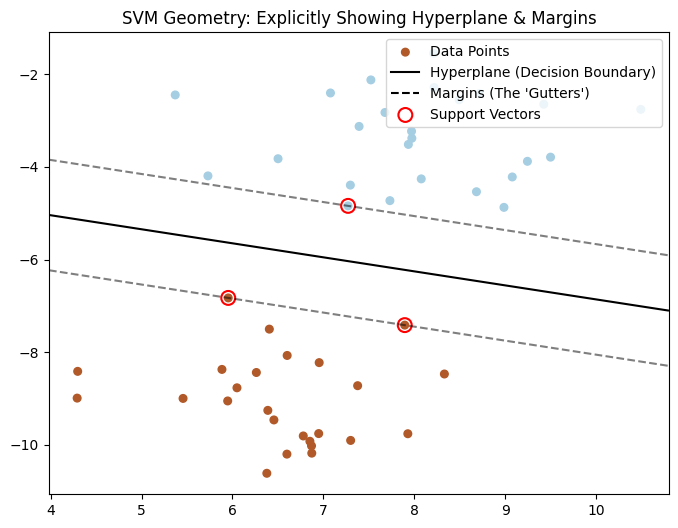

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs

# 1. Create Data
X, y = make_blobs(n_samples=50, centers=2, random_state=6)

# 2. Fit Model
clf = svm.SVC(kernel='linear', C=1)
clf.fit(X, y)

# 3. Visualization
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired, label="Data Points")

# Create grid to evaluate model
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

# --- KEY CHANGE: Plotting with Explicit Labels ---

# A. Plot the Hyperplane (Level 0)
# We plot this separately to give it a specific label in the legend
ax.contour(XX, YY, Z, colors='k', levels=[0], alpha=1, linestyles=['-'])
# Hack to add to legend: plot a dummy line with same style
plt.plot([], [], 'k-', label="Hyperplane (Decision Boundary)")

# B. Plot the Margins (Levels -1 and 1)
ax.contour(XX, YY, Z, colors='k', levels=[-1, 1], alpha=0.5, linestyles=['--'])
# Hack to add to legend
plt.plot([], [], 'k--', label="Margins (The 'Gutters')")

# C. Highlight Support Vectors
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
           linewidth=1.5, facecolors='none', edgecolors='r', label='Support Vectors')

plt.legend(loc="upper right")
plt.title("SVM Geometry: Explicitly Showing Hyperplane & Margins")
plt.show()



## 3. Linearity vs. Non-Linearity (The Kernel Trick)



### Linear SVM
If your data can be separated by a straight line (or flat hyperplane), we use a **Linear Kernel**. This is the simplest form of SVM. However, real-world data is rarely this simple.

### The Challenge
Imagine a dataset where Class A is a cluster in the center, and Class B is a ring surrounding it. A straight line cannot separate them. You would need a circle.

### The Kernel Trick
SVM solves this by projecting the data from a low-dimensional space (where it is not separable) into a **higher-dimensional space** (where it becomes separable).



Think of the "Ring and Cluster" example:
1.  **2D View:** You cannot draw a straight line to separate them.
2.  **3D Projection:** Imagine lifting the center cluster (Class A) up into the air (adding a Z-axis based on distance from the center).
3.  **The Cut:** Now, you can slide a flat sheet (Hyperplane) between the lifted cluster and the ring on the ground.
4.  **Project Back:** When you project this sheet back down to 2D, it looks like a circular boundary.

This mathematical mapping is handled by **Kernels**:
* **Linear Kernel:** No projection. $K(x, y) = x^T y$. Used for text classification or simple data.
* **Polynomial Kernel:** Maps data to curved polynomial lines.
* **Radial Basis Function (RBF) Kernel:** The most popular kernel. It maps data into infinite dimensions based on distance. It creates complex, non-linear boundaries.



In [8]:
from sklearn.svm import SVC
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score

# 1. Generate Non-Linear Data (Concentric Circles)
# A straight line CANNOT separate these.
X, y = make_circles(n_samples=100, factor=0.5, noise=0.1, random_state=42)

# --- SCENARIO A: Linear SVM ---
linear_clf = SVC(kernel='linear')
linear_clf.fit(X, y)
print(f"Linear Kernel Accuracy: {linear_clf.score(X, y):.2f}")

# --- SCENARIO B: Non-Linear/RBF SVM  ---
# The Kernel trick projects this data to 3D to separate it.
rbf_clf = SVC(kernel='rbf', gamma='auto')
rbf_clf.fit(X, y)
print(f"RBF Kernel Accuracy:    {rbf_clf.score(X, y):.2f}")

Linear Kernel Accuracy: 0.54
RBF Kernel Accuracy:    0.98


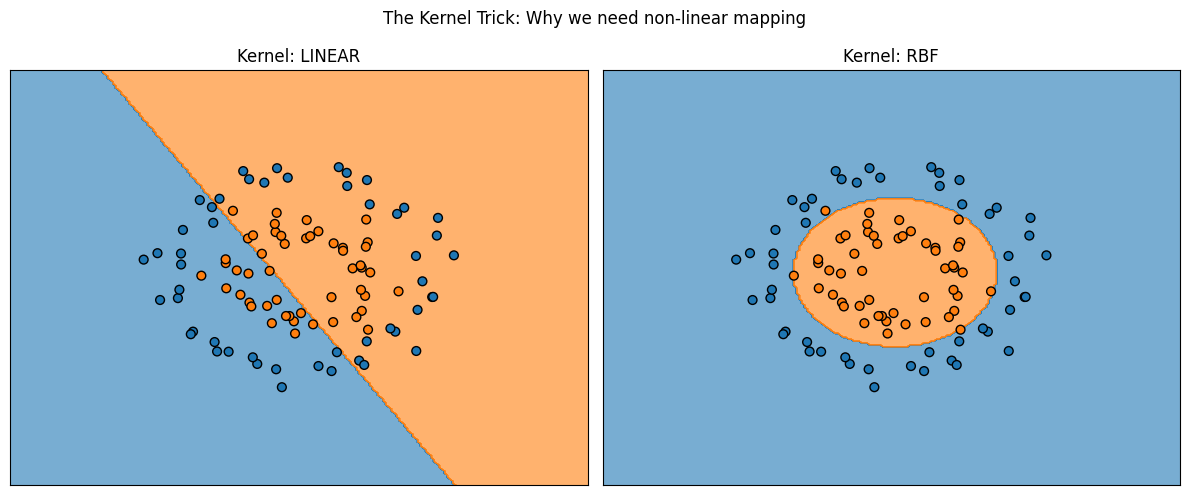

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_circles
# Import ListedColormap to define exact colors
from matplotlib.colors import ListedColormap

# --- CUSTOM COLOR SETUP ---
# Define distinct colors for Class 0 and Class 1.
# Using standard matplotlib blue (#1f77b4) and orange (#ff7f0e).
# This avoids the purple/red gradient completely.
custom_cmap = ListedColormap(['#1f77b4', '#ff7f0e'])

# 1. Create Non-Linear Data (Circles)
X, y = make_circles(n_samples=100, factor=0.5, noise=0.1, random_state=42)

# 2. Setup plotting grid
h = .02  # step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 3. Compare Linear vs RBF
kernels = ['linear', 'rbf']
figure, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, kernel_name in enumerate(kernels):
    # Fit the model
    clf = svm.SVC(kernel=kernel_name, C=1, gamma='auto')
    clf.fit(X, y)

    # Put the result into a color plot
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # --- UPDATED PLOTTING FUNCTIONS ---
    # Use custom_cmap instead of plt.cm.coolwarm
    # Lowered alpha slightly to 0.6 so the background isn't too overwhelming
    axes[i].contourf(xx, yy, Z, cmap=custom_cmap, alpha=0.6)

    # Use the same custom_cmap for scatter points so they match the background regions
    axes[i].scatter(X[:, 0], X[:, 1], c=y, cmap=custom_cmap, edgecolors='k', s=40)

    axes[i].set_title(f"Kernel: {kernel_name.upper()}")
    axes[i].set_xticks(())
    axes[i].set_yticks(())

plt.suptitle("The Kernel Trick: Why we need non-linear mapping")
plt.tight_layout() # Adjusts spacing so titles don't overlap
plt.show()



## 4. Handling Outliers: Hard Margin vs. Soft Margin

Real data is noisy. Sometimes a blue point lies inside the red territory.



### Hard Margin
* **Principle:** strictly prohibits any data points from entering the margin.
* **Risk:** If the data has noise (outliers), a Hard Margin SVM will try to contort the boundary strictly to accommodate that outlier, resulting in a very narrow margin and severe **overfitting**.

### Soft Margin (The Reality)
* **Principle:** Allows some misclassification or points inside the margin to keep the street as wide as possible for the majority of points.
* **Hinge Loss:** This is the cost function used. It penalizes points only if they are on the wrong side of the margin. If a point is correctly classified and outside the margin, the loss is 0.



In [14]:
from sklearn.svm import SVC

# --- SCENARIO A: Soft Margin (The standard "Solution") ---
# C=1.0 is the default. It allows some misclassification to keep the margin wide.
# Use this when data has noise or outliers.
soft_margin_clf = SVC(kernel='linear', C=1.0) 

# --- SCENARIO B: Hard Margin (Risk of Overfitting) ---
# C=1e10 (10,000,000,000) forces the model to classify EVERY point correctly.
# It will skew the boundary aggressively to fit outliers.
hard_margin_clf = SVC(kernel='linear', C=1e10)

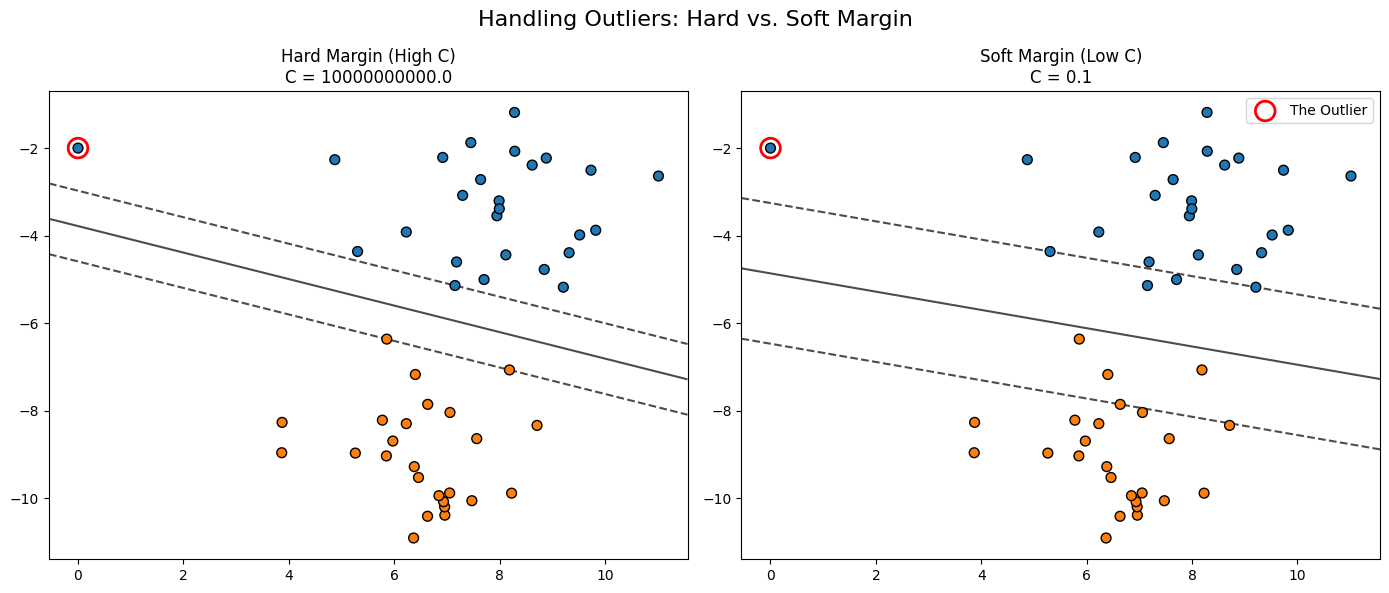

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs
from matplotlib.colors import ListedColormap

# --- CUSTOM COLOR SETUP (Blue/Orange) ---
custom_cmap = ListedColormap(['#1f77b4', '#ff7f0e'])

# 1. Create Data with an OUTLIER
X, y = make_blobs(n_samples=50, centers=2, random_state=6, cluster_std=1.2)
# Manually add a distinct outlier: A point from Class 0 (Blue) sitting deep in Class 1 (Orange)
X = np.vstack([X, [0, -2]]) # The outlier coordinates
y = np.hstack([y, [0]])     # The outlier label (Class 0)

# 2. Setup Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Define the two cases
cases = [
    ("Hard Margin (High C)", 1e10), # Strict, tries to fit the outlier
    ("Soft Margin (Low C)", 0.1)    # Lenient, ignores the outlier
]

for i, (title, c_val) in enumerate(cases):
    # Fit Model
    clf = svm.SVC(kernel='linear', C=c_val)
    clf.fit(X, y)
    
    # Plot Data Points
    axes[i].scatter(X[:, 0], X[:, 1], c=y, s=50, cmap=custom_cmap, edgecolors='k', zorder=10)
    
    # --- PLOT DECISION BOUNDARY & MARGINS ---
    ax = axes[i]
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # Plot Hyperplane (Solid) and Margins (Dashed)
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.7,
               linestyles=['--', '-', '--'])
    
    # Highlight the Outlier (The last point we added)
    ax.scatter(X[-1, 0], X[-1, 1], s=200, facecolors='none', edgecolors='red', linewidth=2, label="The Outlier")

    axes[i].set_title(f"{title}\nC = {c_val}")

plt.suptitle("Handling Outliers: Hard vs. Soft Margin", fontsize=16)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()



## 5. SVM for Classification (SVC)



When using SVM for classification (`SVC` in sklearn), the algorithm handles binary classes natively. For **Multi-Class Classification**, it uses two strategies:

1.  **One-vs-Rest (OvR):** If you have 3 classes (A, B, C), it trains 3 models:
    * A vs. [B, C]
    * B vs. [A, C]
    * C vs. [A, B]
    The class with the highest confidence score wins.
2.  **One-vs-One (OvO):** Trains a model for every pair of classes (A vs B, B vs C, A vs C). This is computationally expensive for many classes but good for small datasets.



In [9]:
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Generate Dummy Classification Data
X, y = make_classification(n_samples=100, n_features=4, random_state=42)

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize SVC (Support Vector Classification)
# We use the RBF kernel by default for most problems
clf = SVC(kernel='rbf', C=1.0, gamma='scale')

# 4. Fit the Model (Train)
clf.fit(X_train, y_train)

# 5. Predict
y_pred = clf.predict(X_test)

# 6. Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Number of Support Vectors: {len(clf.support_vectors_)}")

Accuracy: 90.00%
Number of Support Vectors: 20


## 6. SVM for Regression (SVR)



Support Vector Regression (SVR) flips the script. In Classification, we want the widest street that *separates* the data. In Regression, we want to fit as many data points as possible **inside the street**.



### The $\epsilon$-Insensitive Tube
* We define a tube of width $\epsilon$ (epsilon) around the regression line.
* **The Logic:** Any prediction error falling *inside* this tube is considered "good enough" and is ignored (Loss = 0).
* **The Support Vectors:** The algorithm only cares about minimizing errors for points that fall *outside* the tube. These outside points become the Support Vectors.
* This makes SVR robust to outliers because it doesn't try to chase every single data point perfectly; it just tries to keep the majority within the tube.



In [10]:
from sklearn.svm import SVR
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

# 1. Generate Dummy Regression Data
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# 2. Initialize SVR (Support Vector Regression)
# epsilon=5.0 means: "If the error is less than 5.0, treat it as zero error."
# This creates the "Tube" logic.
regressor = SVR(kernel='rbf', C=10.0, epsilon=5.0)

# 3. Fit the Model
regressor.fit(X, y)

# 4. Predict
y_pred = regressor.predict(X)

# 5. Evaluate
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"Points outside the epsilon-tube (Support Vectors): {len(regressor.support_)}")

Mean Squared Error: 172.98
Points outside the epsilon-tube (Support Vectors): 68


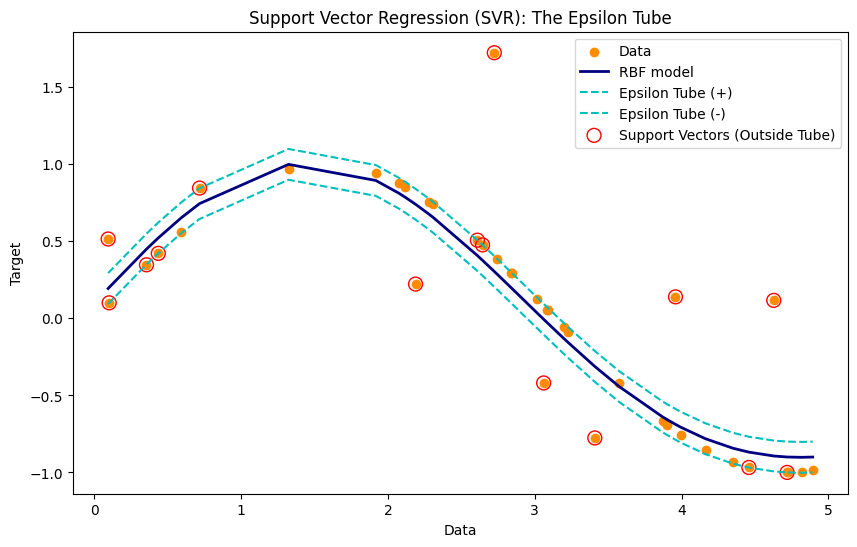

In [4]:
# 1. Generate sample data
np.random.seed(0)
X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.sin(X).ravel()
# Add noise to targets
y[::5] += 3 * (0.5 - np.random.rand(8))

# 2. Fit Regression Model
# Using RBF kernel to capture the sine wave
svr_rbf = svm.SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_rbf.fit(X, y)

# 3. Plot results
lw = 2
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='darkorange', label='Data')
plt.plot(X, svr_rbf.predict(X), color='navy', lw=lw, label='RBF model')

# Visualize the Epsilon Tube
# We add/subtract epsilon from the prediction to show the tube width
plt.plot(X, svr_rbf.predict(X) + svr_rbf.epsilon, color='c', linestyle='--', label='Epsilon Tube (+)')
plt.plot(X, svr_rbf.predict(X) - svr_rbf.epsilon, color='c', linestyle='--', label='Epsilon Tube (-)')

# Highlight Support Vectors
# SVR stores support vectors in support_
plt.scatter(X[svr_rbf.support_], y[svr_rbf.support_], facecolors='none', edgecolors='r', s=100, label='Support Vectors (Outside Tube)')

plt.xlabel('Data')
plt.ylabel('Target')
plt.title('Support Vector Regression (SVR): The Epsilon Tube')
plt.legend()
plt.show()



## 7. Critical Hyperparameters (The "Knobs")

Understanding these is crucial for tuning models beyond default settings.

### 1. C (Regularization Parameter)
Controls the trade-off between a smooth decision boundary and classifying training points correctly.
* **High C (Strict):** "I must classify every training point correctly."
    * Result: Narrow margin, complex boundary. **High Variance (Overfitting).**
* **Low C (Lenient):** "I prefer a wider street, even if I make a few mistakes."
    * Result: Wide margin, simple boundary. **High Bias (Underfitting).**

### 2. Gamma ($\gamma$) (Kernel Coefficient)
Used in non-linear kernels (RBF, Poly). It defines how far the influence of a single training example reaches.
* **High Gamma:** Only nearby points influence the boundary.
    * Result: The boundary wraps tightly around data clusters. Can lead to "islands" of decision boundaries. **Overfitting.**
* **Low Gamma:** Far away points influence the boundary.
    * Result: Smooth, broad boundary lines. **Underfitting.**

### 3. Epsilon ($\epsilon$) (SVR Only)
Defines the width of the tube where no penalty is associated with the training loss function.
* **Larger $\epsilon$:** More tolerance for error, fewer support vectors (simpler model).
* **Smaller $\epsilon$:** Less tolerance, the model tries to fit the data very tightly (risk of overfitting).



```python
from sklearn import svm

# --- 1. The Regularization Parameter (C) ---
# Controls the trade-off: 
# Low C = High Bias (Smoother boundary, wider margin, allows misclassifications)
# High C = High Variance (Strict boundary, narrow margin, penalizes mistakes heavily)
svm_low_c  = svm.SVC(C=0.01) 
svm_high_c = svm.SVC(C=1000.0)

# --- 2. The Kernel Coefficient (Gamma) ---
# Only for non-linear kernels (RBF, Poly, Sigmoid).
# Controls influence distance:
# Low Gamma = 'Far' influence (Gaussian curve is wide/flat) -> Smoother boundary
# High Gamma = 'Near' influence (Gaussian curve is spikey) -> Complex/Island boundaries
svm_low_gamma  = svm.SVC(kernel='rbf', gamma=0.1)
svm_high_gamma = svm.SVC(kernel='rbf', gamma=10.0)

# --- 3. The Tube Width (Epsilon) ---
# SPECIFIC TO REGRESSION (SVR).
# Controls the width of the tube within which errors are ignored.
svr_wide_tube  = svm.SVR(epsilon=0.5) # Looser fit
svr_tight_tube = svm.SVR(epsilon=0.1) # Tighter fit
```

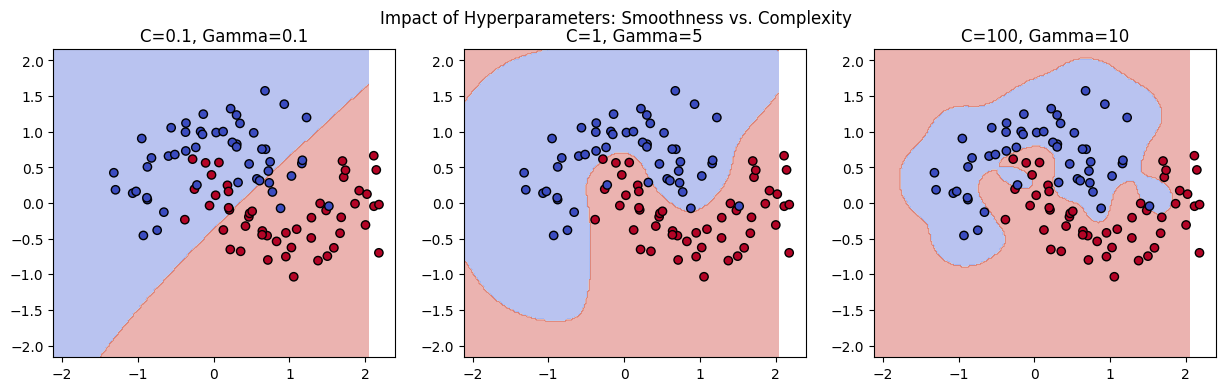

In [3]:
# Create a complex dataset (moons)
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.3, random_state=0)

# Define parameter combinations to test
params = [
    (0.1, 0.1),  # Low C, Low Gamma (Underfitting)
    (1, 5),      # Balanced
    (100, 10),   # High C, High Gamma (Overfitting/Islands)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (C_val, gamma_val) in enumerate(params):
    clf = svm.SVC(kernel='rbf', C=C_val, gamma=gamma_val)
    clf.fit(X, y)

    # Visualization
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[i].contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.4)
    axes[i].scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    axes[i].set_title(f"C={C_val}, Gamma={gamma_val}")

plt.suptitle("Impact of Hyperparameters: Smoothness vs. Complexity")
plt.show()



## 8. Summary: Advantages & Limitations

| Advantages | Limitations |
| :--- | :--- |
| **High Dimensions:** Very effective when the number of dimensions (features) is greater than the number of samples. | **Scalability:** Very slow on large datasets (e.g., >100k rows) due to cubic complexity $O(n^3)$. |
| **Memory Efficient:** Uses only a subset of training points (support vectors). | **Noise Sensitivity:** Sensitive to overlapping classes and outliers if parameters aren't tuned well. |
| **Versatile:** Different Kernel functions can be specified for different data structures. | **Probabilities:** Does not provide probability estimates directly (unlike Logistic Regression). |